## Setup

In [ ]:
!pip -q install "transformers>=4.44,<4.58" datasets accelerate torchvision evaluate "pillow<11" -U

import os
os.environ["WANDB_DISABLED"] = "true"  # silence wandb login prompts


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.3/322.3 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124

In [ ]:
import os, json, random, shutil, glob, math
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import torch
from datasets import load_dataset, DatasetDict
from transformers import AutoImageProcessor, DetrForObjectDetection, TrainingArguments, Trainer, pipeline


## Label Studio export

In [ ]:
from google.colab import files
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
extract_dir = Path("ls_export")
extract_dir.mkdir(parents=True, exist_ok=True)

!unzip -qo "{zip_name}" -d "{extract_dir}"
print("Unzipped to:", extract_dir.resolve())

# Find result.json and images folder

result_json_candidates = list(extract_dir.rglob("result.json"))
images_dir_candidates = [p for p in extract_dir.rglob("*") if p.is_dir() and p.name == "images"]

assert result_json_candidates, "result.json not found in your ZIP"
assert images_dir_candidates, "images/ folder not found in your ZIP"

result_json = result_json_candidates[0]
images_dir = images_dir_candidates[0]
print("result.json:", result_json)
print("images dir:", images_dir)


Saving project-1-at-2025-10-28-22-41-eaea784e.zip to project-1-at-2025-10-28-22-41-eaea784e.zip
Unzipped to: /content/ls_export
result.json: ls_export/result.json
images dir: ls_export/images


## COCO to HUGGINGFACE

In [ ]:
# 1) Read the COCO formatted annotations to a dict

with open(result_json) as f:
    cocodata = json.load(f)

# 2) Convert the COCO formatted dict to a format readable by datasets.load_dataset()

import os
huggingdata = []
for image in cocodata['images']:
    image['file_name'] = image['file_name'].split(os.path.sep)[-1]
    image['image_id'] = image['id']
    image['objects'] = {'bbox': [], 'category': [], 'area': [], 'id': []}
    for annot in cocodata['annotations']:
        if annot['image_id'] == image['id']:
            image['objects']['bbox'].append(annot['bbox'])
            image['objects']['category'].append(annot['category_id'])
            image['objects']['area'].append(annot['area'])
            image['objects']['id'].append(annot['id'])
    huggingdata.append(image)

# Build id2label / label2id
id2label = {item['id']: item['name'] for item in cocodata['categories']}
label2id = {v: k for k, v in id2label.items()}
id2label, label2id


({0: 'Black_star',
  1: 'Cat',
  2: 'Grey_star',
  3: 'Insect',
  4: 'Moon',
  5: 'Owl',
  6: 'Unicorn_head',
  7: 'Unicorn_whole'},
 {'Black_star': 0,
  'Cat': 1,
  'Grey_star': 2,
  'Insect': 3,
  'Moon': 4,
  'Owl': 5,
  'Unicorn_head': 6,
  'Unicorn_whole': 7})

In [ ]:
random.seed(42)
data_root = Path("data")
train_dir = data_root/"train"
val_dir   = data_root/"validation"
train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)

# 80/20 split
n = len(huggingdata)
idxs = list(range(n))
random.shuffle(idxs)
split = math.floor(0.8 * n)
train_idx, val_idx = set(idxs[:split]), set(idxs[split:])

def write_split_jsonl(indices, out_dir):
    meta_path = out_dir/"metadata.jsonl"
    with open(meta_path, "w") as f:
        for i, item in enumerate(huggingdata):
            if i in indices:
                src = images_dir/ item['file_name']
                dst = out_dir / item['file_name']
                if not dst.exists():
                    shutil.copy2(src, dst)
                f.write(json.dumps({
                    "file_name": item["file_name"],
                    "image_id": item["image_id"],
                    "objects": item["objects"]
                }) + "\n")
    return meta_path

train_meta = write_split_jsonl(train_idx, train_dir)
val_meta   = write_split_jsonl(val_idx,   val_dir)

print("Wrote:", train_meta, "and", val_meta)


Wrote: data/train/metadata.jsonl and data/validation/metadata.jsonl


In [ ]:
candy_data = load_dataset("imagefolder", data_dir=str(data_root))
candy_data

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'objects'],
        num_rows: 8
    })
    validation: Dataset({
        features: ['image', 'image_id', 'objects'],
        num_rows: 3
    })
})

## Model + transforms

In [ ]:
checkpoint = "facebook/detr-resnet-50"
processor = AutoImageProcessor.from_pretrained(checkpoint)
model = DetrForObjectDetection.from_pretrained(
    checkpoint,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Attach a transform that converts images + annotations to model inputs on-the-fly
def set_transform(example_batch):
    images = [img.convert("RGB") for img in example_batch["image"]]
    annotations = []
    for objs in example_batch["objects"]:
        anns = []
        for bbox, cat in zip(objs["bbox"], objs["category"]):
            # COCO bbox: [x, y, width, height]
            anns.append({"bbox": bbox, "category_id": int(cat), "iscrowd": 0, "area": 0})
        annotations.append({"image_id": 0, "annotations": anns})
    encodings = processor(images=images, annotations=annotations, return_tensors="pt")
    return {
        "pixel_values": encodings["pixel_values"],
        "labels": encodings["labels"]
    }

candy_data = candy_data.with_transform(set_transform)

def collate_fn(batch):
    pixel_values = torch.stack([b["pixel_values"] for b in batch])
    labels = [b["labels"] for b in batch]
    return {"pixel_values": pixel_values, "labels": labels}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2446: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

## Train

In [ ]:
# 6) Train (version-agnostic TrainingArguments, minimal + assignment-faithful)

import inspect, transformers, torch
from transformers import TrainingArguments, Trainer

def make_training_args():
    params = set(inspect.signature(TrainingArguments.__init__).parameters)
    kw = dict(
        output_dir="candy_detr_runs",
        num_train_epochs=230,              # raise to 60–100 if needed for mAP
        per_device_train_batch_size=2,
        per_device_eval_batch_size=2,
        learning_rate=3.5e-5,
        weight_decay=1e-5,
        logging_steps=10,                 # see loss every 10 steps
        load_best_model_at_end=True,
    )

    # Keep columns needed by our with_transform

    if "remove_unused_columns" in params:
        kw["remove_unused_columns"] = False

    # Evaluation & saving each epoch (handle naming differences)

    if "evaluation_strategy" in params:
        kw["evaluation_strategy"] = "epoch"
    elif "eval_strategy" in params:
        kw["eval_strategy"] = "epoch"
    else:
        kw["do_eval"] = True
    if "save_strategy" in params:
        kw["save_strategy"] = "epoch"

    # Silence external loggers to avoid W&B prompts

    if "report_to" in params:
        kw["report_to"] = "none"

    # Mixed precision if available and supported

    if torch.cuda.is_available() and "fp16" in params:
        kw["fp16"] = True
    return TrainingArguments(**kw)

args = make_training_args()

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=candy_data["train"],
    eval_dataset=candy_data["validation"],
    data_collator=collate_fn,
    tokenizer=processor,  # fine for image processors
)

train_result = trainer.train()
train_result


/tmp/ipython-input-894090558.py:40: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,No log,2.642630
2,No log,2.597961
3,2.799100,2.492827
4,2.799100,2.460983
5,2.490200,2.444909
6,2.490200,2.400280
7,2.490200,2.376592
8,2.354000,2.355677
9,2.354000,2.357722
10,2.298200,2.335983


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument i

Epoch,Training Loss,Validation Loss
1,No log,2.642630
2,No log,2.597961
3,2.799100,2.492827
4,2.799100,2.460983
5,2.490200,2.444909
6,2.490200,2.400280
7,2.490200,2.376592
8,2.354000,2.355677
9,2.354000,2.357722
10,2.298200,2.335983


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument i

TrainOutput(global_step=320, training_loss=2.0340871572494508, metrics={'train_runtime': 9600.0744, 'train_samples_per_second': 0.067, 'train_steps_per_second': 0.033, 'total_flos': 4.07488889014272e+17, 'train_loss': 2.0340871572494508, 'epoch': 80.0})

In [4]:
# Save model + processor exactly as instructed

trainer.save_model("candy_detector")
# Use the model's processor to save, which should include all necessary files
model.processor.save_pretrained("candy_detector")
print("Saved to ./candy_detector")

NameError: name 'trainer' is not defined

In [ ]:
# Zip it for submission
import os, shutil
zip_path = "candy_detector.zip"
if os.path.exists(zip_path):
    os.remove(zip_path)
shutil.make_archive("candy_detector", "zip", root_dir="candy_detector")
print("Zipped model at ./candy_detector.zip")

Zipped model at ./candy_detector.zip


Device set to use cpu


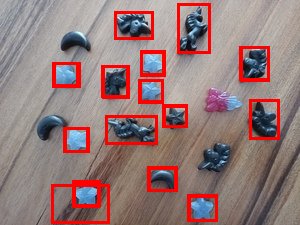

In [ ]:
from transformers import pipeline
from PIL import Image, ImageDraw

# pick one validation example from your DatasetDict

sample = candy_data["validation"][0]

# Access the original image using the image_id from the sample

image_id = sample["labels"]["image_id"][0].item() # Access the first element of the tensor and get the scalar value

# Find the corresponding image data in the original huggingdata list

original_image_data = None
for img_data in huggingdata:
    if img_data['image_id'] == image_id:
        original_image_data = img_data
        break

if original_image_data is None:
    raise ValueError(f"Original image with id {image_id} not found in huggingdata.")

# Construct the full path to the image file

image_path = data_root / "validation" / original_image_data['file_name']

# Open the image using PIL

img = Image.open(image_path).convert("RGB")


detector = pipeline("object-detection", model="candy_detector")

# brief tip from the brief: threshold may need lowering for tiny datasets

preds = detector(img, threshold=0.15)  # you can nudge 0.25–0.5

draw = ImageDraw.Draw(img)
for p in preds:
    b = p["box"]
    draw.rectangle([(b["xmin"], b["ymin"]), (b["xmax"], b["ymax"])], outline=(255,0,0), width=3)

img.save("validation_prediction.png")
img

In [ ]:
# Even without an eval strategy during training, you can still call:

eval_metrics = trainer.evaluate(eval_dataset=candy_data["validation"])
eval_metrics


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.9900366067886353,
 'eval_runtime': 12.8356,
 'eval_samples_per_second': 0.234,
 'eval_steps_per_second': 0.156,
 'epoch': 80.0}

In [12]:
!rm -r candy_detector

In [13]:
# === LAST CELL ONLY ===

# Step 1: Upload one image

from google.colab import files
import numpy as np
from PIL import Image
from transformers import pipeline, AutoImageProcessor, DetrForObjectDetection
import torch
import zipfile
import os

uploaded = files.upload()

# Step 2: Extract the filename

image_name = list(uploaded.keys())[0]
print("Uploaded image name:", image_name)


# Step 3: Create a directory for the extracted model if it doesn't exist
with zipfile.ZipFile('candy_detector.zip', 'r') as zip_ref:
    zip_ref.extractall()

def candy_counter(image):
    """
    Accepts an HxWx3 RGB NumPy array or a PIL.Image of a candy photo and
    returns a dict {class_name: count} using the fine-tuned detector.
    """

    # Load the fine-tuned model and processor from the local directory

    processor = AutoImageProcessor.from_pretrained("./candy_detector", local_files_only=True)
    model = DetrForObjectDetection.from_pretrained("./candy_detector", local_files_only=True)

    # Normalize input to a PIL image

    if isinstance(image, np.ndarray):
        if image.ndim != 3 or image.shape[2] != 3:
            raise ValueError("Expected HxWx3 RGB NumPy array.")
        pil = Image.fromarray(image.astype("uint8"), "RGB")
    elif hasattr(image, "convert"):
        pil = image.convert("RGB")
    else:
        raise ValueError("Input must be a NumPy RGB array or PIL.Image.")

    # Prepare image for the model

    inputs = processor(images=pil, return_tensors="pt")

    # Run inference

    with torch.no_grad():
        outputs = model(**inputs)

    # Post-process the outputs

    target_sizes = torch.tensor([pil.size[::-1]])
    results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.15)[0]


    # Required classes

    classes = ['Moon','Insect','Black_star','Grey_star','Unicorn_whole','Unicorn_head','Owl','Cat']
    counts = {k: 0 for k in classes}

    # Count detected objects

    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        if model.config.id2label[label.item()] in counts:
            counts[model.config.id2label[label.item()]] += 1

    return counts


# Example:

image = np.array(Image.open(image_name).convert("RGB"))
candy_counter(image)

Saving cd_04.jpg to cd_04 (6).jpg
Uploaded image name: cd_04 (6).jpg


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

{'Moon': 2,
 'Insect': 0,
 'Black_star': 3,
 'Grey_star': 7,
 'Unicorn_whole': 4,
 'Unicorn_head': 2,
 'Owl': 0,
 'Cat': 0}